In [2]:
!pip install google-play-scraper textblob seaborn -q
!pip install deep-translator -q
!pip install indonlp==0.2.0
!pip install wordcloud -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.6/110.6 kB 4.5 MB/s eta 0:00:00


In [3]:
from google_play_scraper import app, Sort, reviews_all
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format='retina'
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15,10)

In [9]:
app_id = 'org.telegram.messenger'
languages = ['en', 'id', 'es', 'my'] # Inggris, Indonesia, Spanyol, Melayu

all_reviews_data = []

for lang_code in languages:
    result = reviews_all(
        app_id,
        lang='id',
        country='id',
        sort=Sort.NEWEST,
    )
    all_reviews_data.extend(result)
len(all_reviews_data)

1527793

In [10]:
df = pd.DataFrame(all_reviews_data)
df.to_csv('tele_dataset_raw.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527793 entries, 0 to 1527792
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   reviewId              1527793 non-null  object        
 1   userName              1527793 non-null  object        
 2   userImage             1527793 non-null  object        
 3   content               1527565 non-null  object        
 4   score                 1527793 non-null  int64         
 5   thumbsUpCount         1527793 non-null  int64         
 6   reviewCreatedVersion  966721 non-null   object        
 7   at                    1527793 non-null  datetime64[ns]
 8   replyContent          126448 non-null   object        
 9   repliedAt             126448 non-null   datetime64[ns]
 10  appVersion            966721 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 128.2+ MB


In [8]:
df.head()

,content,score
0,"This sticker on Telegram is annoying, it's bee...",1
1,Very unsafe and disappointing app. There are t...,1
2,This app used to be great. It was very secure ...,3
3,Not useable. I have been trying to register my...,1
4,"Best chat app with features unlike any others,...",3


In [11]:
# Distribution of reviews score
df['score'].value_counts()

,count
score,
5,824442
1,398155
4,125346
3,101240
2,78610


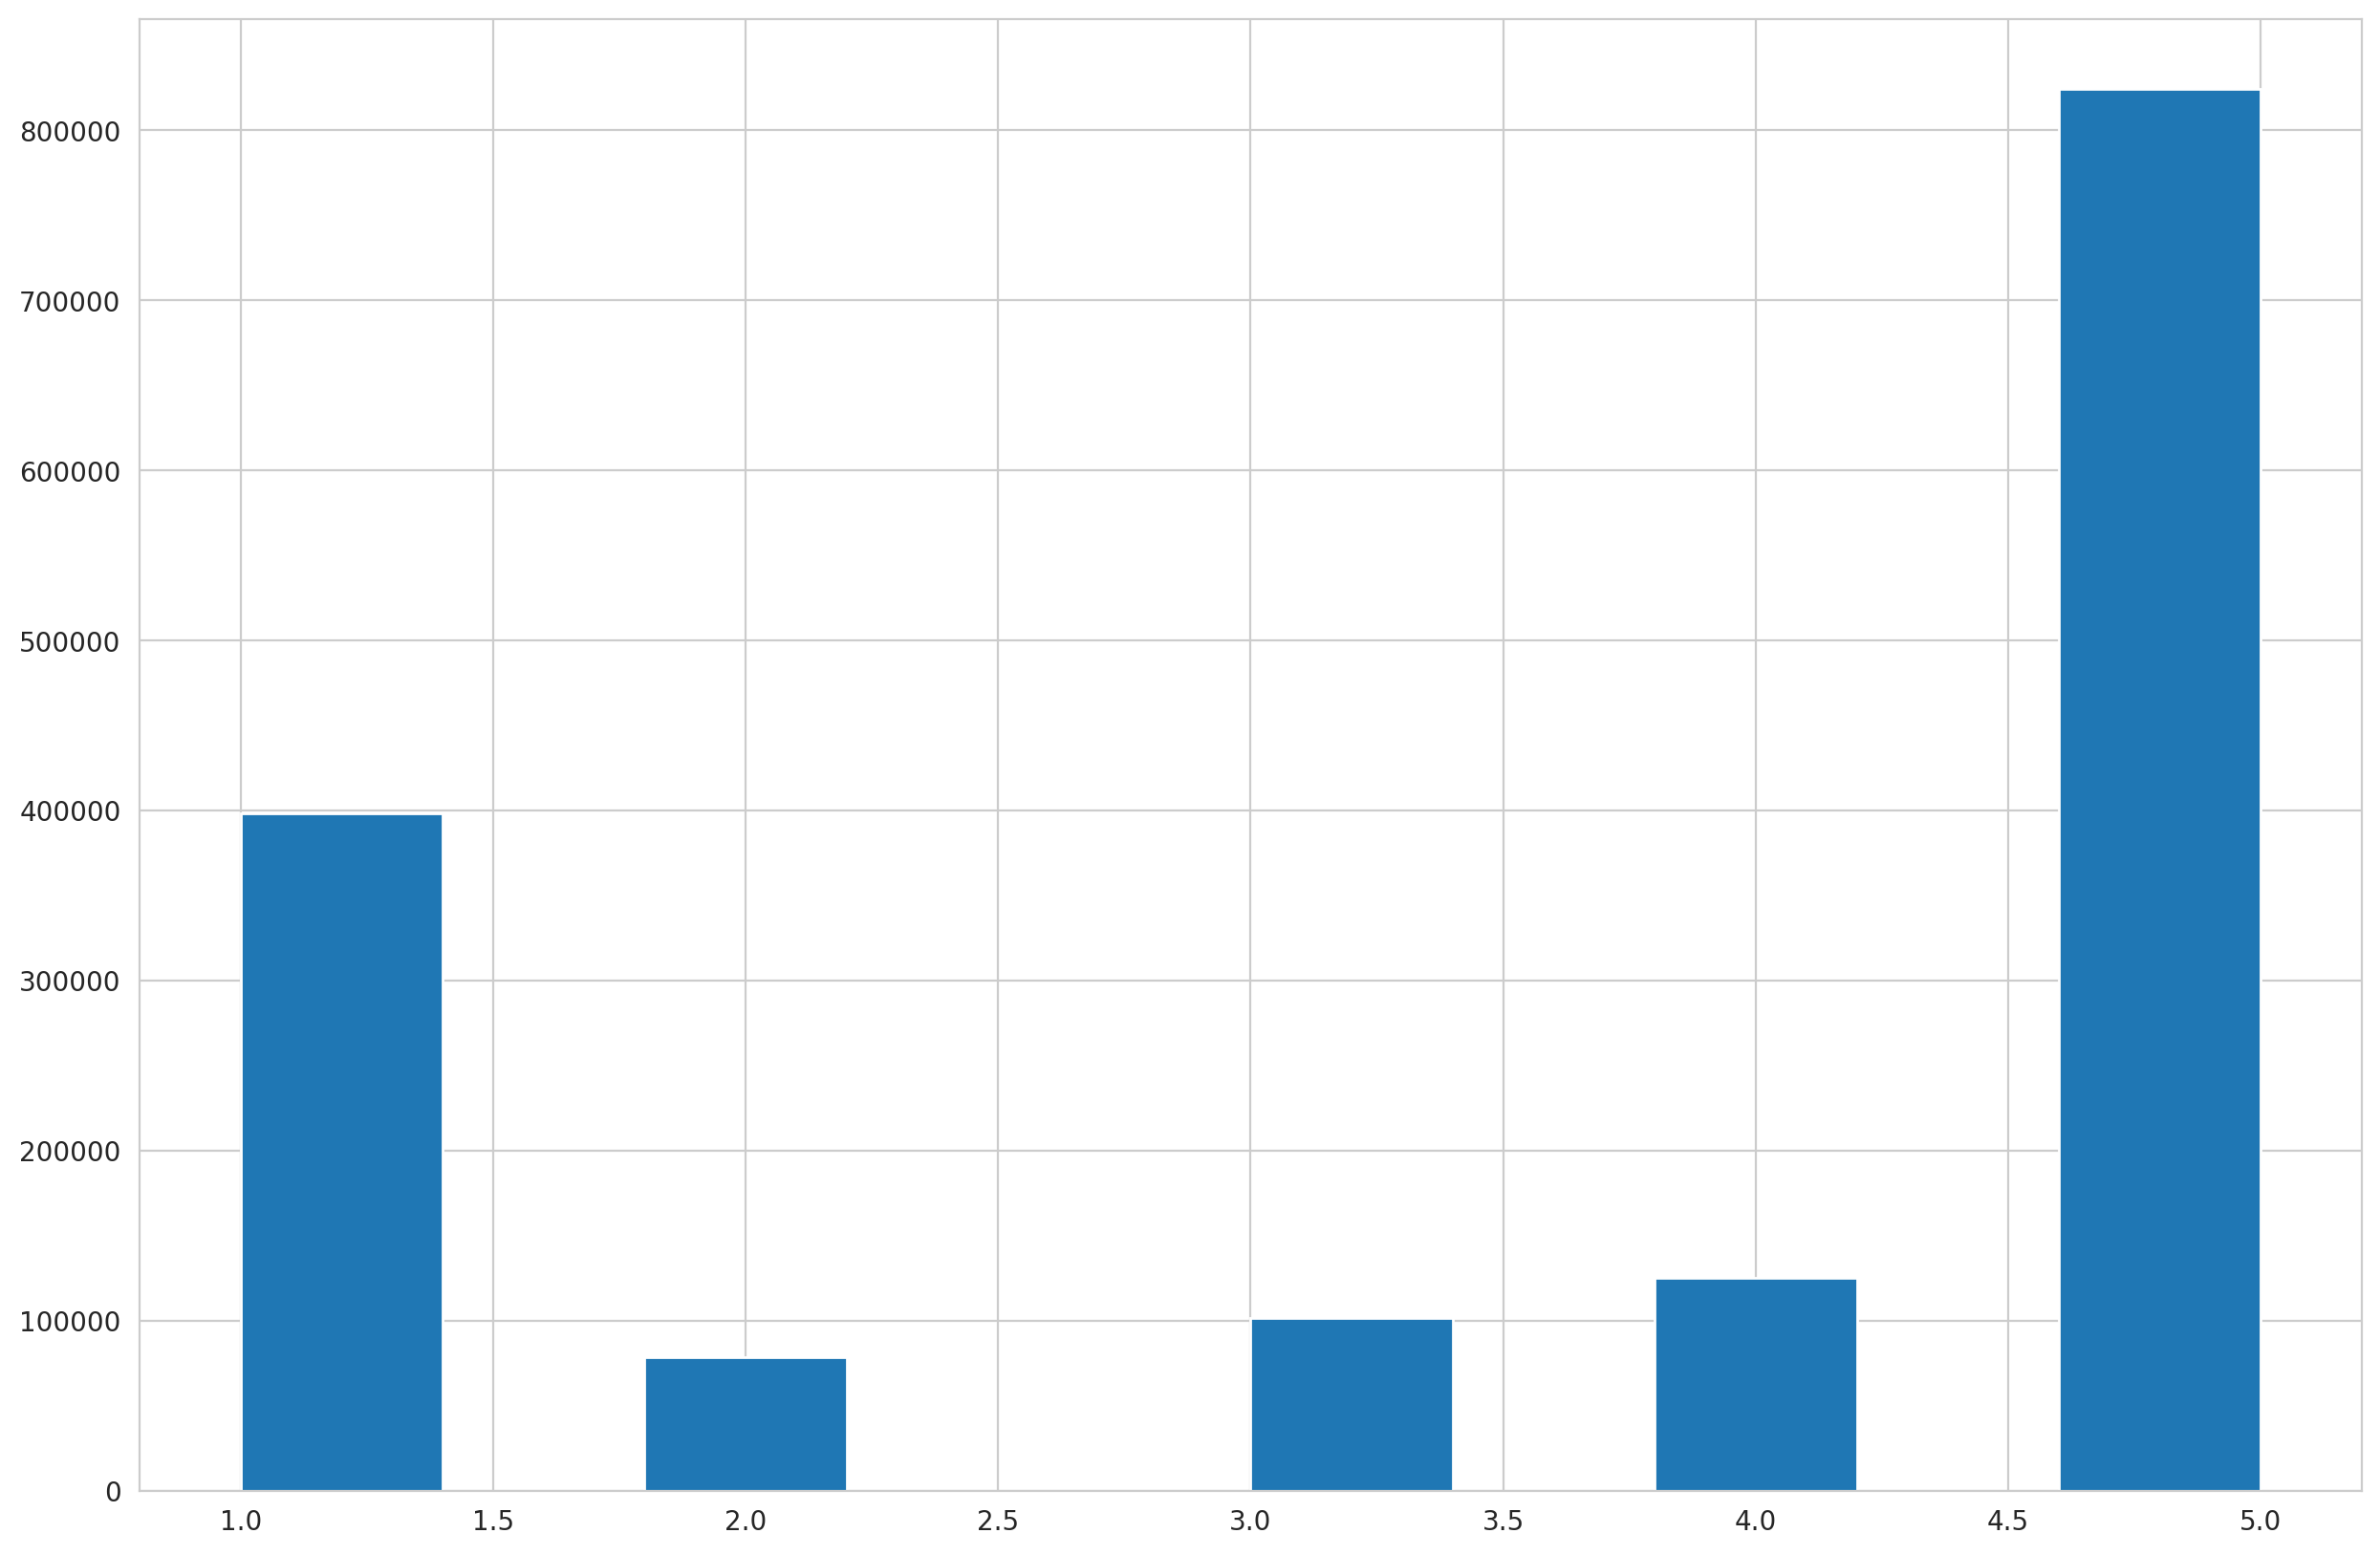

In [13]:
plt.hist(df['score'])
plt.show()